# Metals Model Comparison — New Labels
**Selection table source:** `outputs/model_comparison/selection_table.csv`
**Labels:** `data/meta/triple_barrier_labels.csv` (new triple-barrier labels)
**Champions (all RF):**

| Instrument | Group | AUC | lower CI | Signal |
|-----------|-------|-----|---------|--------|
| gc1s | precious | 0.4866 | 0.3734 | ✗ NO SIGNAL |
| si1s | precious | 0.5400 | 0.4762 | ✗ NO SIGNAL |
| pl1s | precious | 0.5697 | 0.5396 | ✓ SIGNAL |
| hg1s | hg1s     | 0.5463 | 0.5058 | ✓ SIGNAL |

**gc1s / si1s / pl1s** — pooled `precious` RF: each variant is a **separate precious-pool refit** on that instrument's feature subset, trained on all pooled precious rows, scored on the target instrument's own CPCV slice (Phase 1) or sealed-test slice (Phase 2).
**hg1s** — individual RF.

**Lock rule:** simplest variant within **1 cross-path std** of full.
**Train / test split:** global cut 2021-10-06; embargo end 2021-10-20.
**Test scored once** after the lock is committed.

---


In [1]:
import warnings
warnings.filterwarnings("ignore")

import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from IPython.display import display

_HERE = Path().resolve()
while _HERE.name != "new_work" and _HERE != _HERE.parent:
    _HERE = _HERE.parent
assert _HERE.name == "new_work", "Could not find new_work directory"

METALS_OUT = _HERE / "outputs" / "model_comparison" / "metals"
SEL_TABLE  = _HERE / "outputs" / "model_comparison" / "selection_table.csv"

sel      = pd.read_csv(SEL_TABLE, index_col="instrument")
cpcv_df  = pd.read_csv(METALS_OUT / "cpcv_results.csv")
lock_df  = pd.read_csv(METALS_OUT / "locked_picks.csv")
oos_df   = pd.read_csv(METALS_OUT / "oos_results.csv")

locked = dict(zip(lock_df["inst"], lock_df["locked_variant"]))

SIMPLICITY = ["reduced", "pruned", "full"]  # simplest → most complex

def fmt(v, decimals=4):
    return "—" if pd.isna(v) else f"{v:.{decimals}f}"

print(f"CPCV rows: {len(cpcv_df)}  |  OOS rows: {len(oos_df)}")
print(f"Locked picks: {locked}")


CPCV rows: 12  |  OOS rows: 12
Locked picks: {'gc1s': 'reduced', 'si1s': 'reduced', 'pl1s': 'reduced', 'hg1s': 'reduced'}


## Variant Definitions

All reduced sets are **SHAP representatives** — raw features only (no PCA inputs).

### gc1s — precious / RF | NO SIGNAL (exploratory)
| Variant | Feature set | Rationale |
|---------|------------|-----------|
| **full** | All 103 precious-pool features | Baseline |
| **pruned** | C5_hmm_vol + C10_f11_lowfreq_macro + C2_f1 | Top-3 clusters by raw MDA (all non-significant) |
| **reduced** | hmm_vol_p0_calm, hmm_vol_p2_turbulent, hmm_vol_next_turbulent, f11_ust_10y_5d_change, f11_bund_10y_5d_change, f11_real_yield_10y, f6_ts_momentum_20 | 3 HMM-vol states + 3 key rates + 1 trend signal |

### si1s — precious / RF | NO SIGNAL (~random, exploratory)
| Variant | Feature set | Rationale |
|---------|------------|-----------|
| **full** | All 103 precious-pool features | Baseline |
| **pruned** | C5_hmm_vol + C15_f11_lowfreq_macro + C13_f11_lowfreq_macro | Top-3 clusters by raw MDA |
| **reduced** | hmm_vol_p0_calm, hmm_vol_p2_turbulent, hmm_vol_next_turbulent, f2_atr_14, f11_ust_10y_5d_change, f11_real_yield_10y | 3 HMM-vol states + ATR + 2 rates |

### pl1s — precious / RF | SIGNAL (marginal, lower CI 0.54)
| Variant | Feature set | Rationale |
|---------|------------|-----------|
| **full** | All 103 precious-pool features | Baseline |
| **pruned** | C5_hmm_vol + C11_f11 | The **2 significant** clusters from importance analysis |
| **reduced** | hmm_vol_p0_calm, hmm_vol_p2_turbulent, hmm_vol_next_turbulent, f2_atr_14, f6_adx_14, f6_macd_hist_12_26_9, f11_ust_10y_5d_change | SHAP reps from sig clusters (HMM-vol C5, adx C11) + add-ons |

Note — **sig-cluster reps** (pl1s): hmm states + f2_atr_14 from C5_hmm_vol; f6_adx_14 from C11_f11.
**SHAP-singleton add-ons** (from non-significant clusters): f6_macd_hist_12_26_9, f11_ust_10y_5d_change — comparison shows whether they earn their place.

### hg1s — individual / RF | SIGNAL (marginal, lower CI 0.51)
| Variant | Feature set | Rationale |
|---------|------------|-----------|
| **full** | All 101 hg1s features | Baseline |
| **pruned** | C1_f1 + C12_f11 | The **2 significant** clusters from importance analysis |
| **reduced** | f1_mr_score_40, f1_hilo_pos_10, f1_dist_ma_sigma_20, f11_ust_bund_spread, f1_rsi_14, f11_dxy_z, f12_mra_energy_D4 | SHAP reps from sig clusters + add-ons |

Note — **sig-cluster reps** (hg1s): f1_mr_score_40, f1_hilo_pos_10, f1_dist_ma_sigma_20 from C1_f1; f11_ust_bund_spread from C12_f11.
**SHAP-singleton add-ons**: f1_rsi_14, f11_dxy_z, f12_mra_energy_D4 — from non-significant clusters.

---


---
## Phase 1 — CPCV Variant Scoring (Train Only)

In [2]:
# ── Phase 1: CPCV summary table ───────────────────────────────────────────────
print("Phase 1 — CPCV variant scoring (TRAIN only, 15 CPCV paths)")
print("Lock rule: simplest variant within 1 std of full\n")

rows = []
for inst in ["gc1s", "si1s", "pl1s", "hg1s"]:
    sub   = cpcv_df[cpcv_df["inst"] == inst]
    full  = sub[sub["variant"] == "full"].iloc[0]
    thresh = float(full["auc_mean"]) - float(full["auc_std"])
    for v in SIMPLICITY + ["full"]:
        r = sub[sub["variant"] == v]
        if r.empty:
            continue
        r = r.iloc[0]
        rows.append({
            "Instrument": inst,
            "Variant": v,
            "AUC mean": round(float(r["auc_mean"]), 4),
            "AUC std":  round(float(r["auc_std"]),  4),
            "Log-loss": round(float(r["logloss"]),   4),
            "Brier":    round(float(r["brier"]),     4),
            "n paths":  int(r["n_paths"]),
            "Threshold": round(thresh, 4),
            "LOCKED": "← LOCKED" if locked.get(inst) == v else "",
        })

phase1_df = pd.DataFrame(rows)
display(
    phase1_df.style
    .format({"AUC mean": "{:.4f}", "AUC std": "{:.4f}",
             "Log-loss": "{:.4f}", "Brier": "{:.4f}", "Threshold": "{:.4f}"})
    .apply(lambda col: ["background-color: #e3f2fd" if v == "← LOCKED" else ""
                        for v in phase1_df["LOCKED"]], axis=0)
    .set_caption("Phase 1 CPCV — all variants (15 paths, train only)")
)


Phase 1 — CPCV variant scoring (TRAIN only, 15 CPCV paths)
Lock rule: simplest variant within 1 std of full



,Instrument,Variant,AUC mean,AUC std,Log-loss,Brier,n paths,Threshold,LOCKED
0,gc1s,reduced,0.5673,0.1003,0.6852,0.2460,15,0.4138,← LOCKED
1,gc1s,pruned,0.5594,0.1083,0.6953,0.2510,15,0.4138,
2,gc1s,full,0.5270,0.1132,0.7016,0.2542,15,0.4138,
3,gc1s,full,0.5270,0.1132,0.7016,0.2542,15,0.4138,
4,si1s,reduced,0.5817,0.0570,0.6729,0.2401,15,0.4785,← LOCKED
5,si1s,pruned,0.5808,0.0590,0.6760,0.2415,15,0.4785,
6,si1s,full,0.5423,0.0638,0.6873,0.2470,15,0.4785,
7,si1s,full,0.5423,0.0638,0.6873,0.2470,15,0.4785,
8,pl1s,reduced,0.5872,0.0417,0.6854,0.2461,15,0.5452,← LOCKED
9,pl1s,pruned,0.5670,0.0436,0.6868,0.2468,15,0.5452,


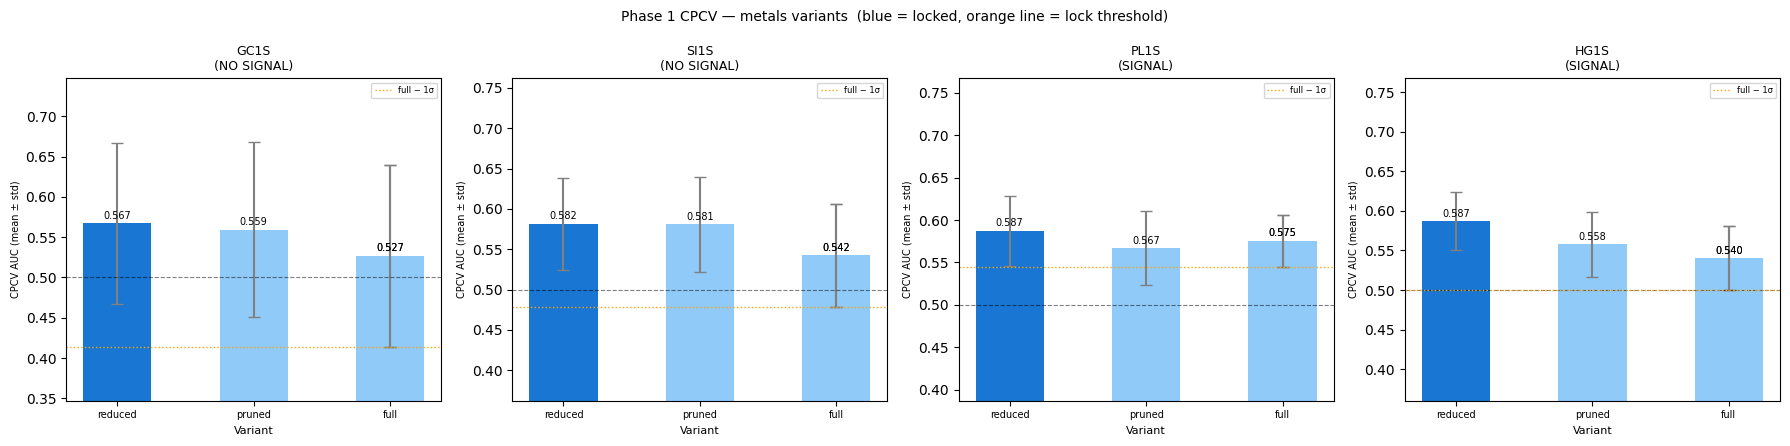

In [3]:
# ── Phase 1 charts ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
for ax, inst in zip(axes, ["gc1s", "si1s", "pl1s", "hg1s"]):
    sub   = cpcv_df[cpcv_df["inst"] == inst]
    variants = SIMPLICITY + ["full"]
    sub_ord  = pd.DataFrame([
        sub[sub["variant"] == v].iloc[0] if not sub[sub["variant"] == v].empty
        else {"variant": v, "auc_mean": np.nan, "auc_std": 0}
        for v in variants
    ])
    means  = sub_ord["auc_mean"].astype(float).tolist()
    stds   = sub_ord["auc_std"].astype(float).tolist()
    colors = ["#1976D2" if v == locked.get(inst) else "#90CAF9" for v in variants]
    ax.bar(variants, means, yerr=stds, color=colors,
           error_kw={"ecolor": "grey", "capsize": 4}, width=0.5)
    ax.axhline(0.5, color="black", linestyle="--", lw=0.8, alpha=0.5)
    full_m  = float(sub[sub["variant"] == "full"].iloc[0]["auc_mean"])
    full_sd = float(sub[sub["variant"] == "full"].iloc[0]["auc_std"])
    ax.axhline(full_m - full_sd, color="orange", linestyle=":", lw=1.0,
               label="full − 1σ")
    valid = [m for m in means if not np.isnan(m)]
    lo = max(0.3, min(valid) - 0.18) if valid else 0.3
    hi = min(0.9, max(valid) + 0.18) if valid else 0.9
    ax.set_ylim(lo, hi)
    s = sel.loc[inst]
    signal = "SIGNAL" if s["signal"] else "NO SIGNAL"
    ax.set_title(f"{inst.upper()}\n({signal})", fontsize=9)
    ax.set_xlabel("Variant", fontsize=8)
    ax.set_ylabel("CPCV AUC (mean ± std)", fontsize=7)
    ax.tick_params(axis="x", labelsize=7)
    for bar, m in zip(ax.patches, means):
        if not np.isnan(m):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.003,
                    f"{m:.3f}", ha="center", va="bottom", fontsize=7)
    ax.legend(fontsize=6)

plt.suptitle("Phase 1 CPCV — metals variants  (blue = locked, orange line = lock threshold)",
             fontsize=10)
plt.tight_layout()
plt.show()


---
## Locked Picks (Committed Before Phase 2)

In [4]:
# ── Locked picks (committed before Phase 2) ───────────────────────────────────
print("=" * 60)
print("LOCKED PICKS — committed before Phase 2 / sealed test")
print("=" * 60)
for inst in ["gc1s", "si1s", "pl1s", "hg1s"]:
    s     = sel.loc[inst]
    lv    = locked[inst]
    sub   = cpcv_df[cpcv_df["inst"] == inst]
    full  = sub[sub["variant"] == "full"].iloc[0]
    lrow  = sub[sub["variant"] == lv].iloc[0]
    thresh = float(full["auc_mean"]) - float(full["auc_std"])
    signal = "SIGNAL" if s["signal"] else "NO SIGNAL"
    print(f"\n  {inst.upper()} ({signal}) — locked: {lv}")
    print(f"    full AUC={full['auc_mean']:.4f} ± {full['auc_std']:.4f}"
          f"  threshold={thresh:.4f}")
    print(f"    {lv} AUC={lrow['auc_mean']:.4f} ± {lrow['auc_std']:.4f}"
          f"  margin above threshold={lrow['auc_mean'] - thresh:+.4f}")
    print(f"    Reason: {lv} is the simplest variant within 1σ of full")


LOCKED PICKS — committed before Phase 2 / sealed test

  GC1S (NO SIGNAL) — locked: reduced
    full AUC=0.5270 ± 0.1132  threshold=0.4138
    reduced AUC=0.5673 ± 0.1003  margin above threshold=+0.1535
    Reason: reduced is the simplest variant within 1σ of full

  SI1S (NO SIGNAL) — locked: reduced
    full AUC=0.5423 ± 0.0638  threshold=0.4785
    reduced AUC=0.5817 ± 0.0570  margin above threshold=+0.1032
    Reason: reduced is the simplest variant within 1σ of full

  PL1S (SIGNAL) — locked: reduced
    full AUC=0.5754 ± 0.0301  threshold=0.5452
    reduced AUC=0.5872 ± 0.0417  margin above threshold=+0.0419
    Reason: reduced is the simplest variant within 1σ of full

  HG1S (SIGNAL) — locked: reduced
    full AUC=0.5403 ± 0.0405  threshold=0.4998
    reduced AUC=0.5873 ± 0.0368  margin above threshold=+0.0875
    Reason: reduced is the simplest variant within 1σ of full


---
## Phase 2 — Single-Shot OOS (Sealed Test)

In [5]:
# ── Phase 2: OOS results ──────────────────────────────────────────────────────
print("Phase 2 — single-shot OOS on SEALED TEST (scored once)\n")

rows2 = []
for inst in ["gc1s", "si1s", "pl1s", "hg1s"]:
    s   = sel.loc[inst]
    lv  = locked[inst]
    sub = oos_df[oos_df["inst"] == inst].copy()
    for _, r in sub.iterrows():
        tag = "HEADLINE [LOCKED]" if r["variant"] == lv else "diagnostic"
        rows2.append({
            "Instrument": inst,
            "Variant":    r["variant"],
            "Role":       tag,
            "OOS AUC":    round(float(r["auc"]), 4),
            "CI lo":      round(float(r["auc_ci_lo"]), 3),
            "CI hi":      round(float(r["auc_ci_hi"]), 3),
            "Log-loss":   round(float(r["logloss"]), 4),
            "Brier":      round(float(r["brier"]), 4),
            "n test":     int(r["n_test"]),
        })

oos_display = pd.DataFrame(rows2)
display(
    oos_display.style
    .format({"OOS AUC": "{:.4f}", "CI lo": "{:.3f}", "CI hi": "{:.3f}",
             "Log-loss": "{:.4f}", "Brier": "{:.4f}"})
    .apply(lambda col: [
        "background-color: #e8f5e9" if "HEADLINE" in str(v) else
        "background-color: #fff9c4" if "diagnostic" in str(v) else ""
        for v in oos_display["Role"]
    ], axis=0)
    .set_caption(
        "Phase 2 OOS — green = locked headline; yellow = diagnostic only (not used for selection)"
    )
)
print("\n⚠️  Diagnostic variants: scored for transparency only — never used to re-pick.")


Phase 2 — single-shot OOS on SEALED TEST (scored once)



,Instrument,Variant,Role,OOS AUC,CI lo,CI hi,Log-loss,Brier,n test
0,gc1s,full,diagnostic,0.4333,0.192,0.692,0.7123,0.2595,23
1,gc1s,pruned,diagnostic,0.4167,0.187,0.675,0.7267,0.2666,23
2,gc1s,reduced,HEADLINE [LOCKED],0.4167,0.167,0.679,0.7468,0.2762,23
3,si1s,full,diagnostic,0.4913,0.398,0.601,0.6962,0.2515,144
4,si1s,pruned,diagnostic,0.6116,0.518,0.708,0.6908,0.2488,144
5,si1s,reduced,HEADLINE [LOCKED],0.5668,0.476,0.663,0.7014,0.2540,144
6,pl1s,full,diagnostic,0.5368,0.441,0.634,0.6886,0.2477,148
7,pl1s,pruned,diagnostic,0.4996,0.402,0.601,0.6914,0.2491,148
8,pl1s,reduced,HEADLINE [LOCKED],0.4984,0.393,0.596,0.6939,0.2503,148
9,hg1s,full,diagnostic,0.4430,0.355,0.540,0.7296,0.2678,164



⚠️  Diagnostic variants: scored for transparency only — never used to re-pick.


In [6]:
# ── Dev-CPCV vs OOS gap ───────────────────────────────────────────────────────
print("\nDev-CPCV vs OOS gap — locked variants only")
print("-" * 64)
for inst in ["gc1s", "si1s", "pl1s", "hg1s"]:
    lv   = locked[inst]
    c    = cpcv_df[(cpcv_df["inst"] == inst) & (cpcv_df["variant"] == lv)].iloc[0]
    o    = oos_df[(oos_df["inst"]  == inst) & (oos_df["variant"]  == lv)].iloc[0]
    dev  = float(c["auc_mean"])
    oos  = float(o["auc"])
    cilo = float(o["auc_ci_lo"])
    cihi = float(o["auc_ci_hi"])
    gap  = dev - oos
    s    = sel.loc[inst]
    signal = "SIGNAL" if s["signal"] else "NO SIGNAL"
    print(f"  {inst:6s} ({lv:8s}) | {signal:9s} | "
          f"dev={dev:.4f}  OOS={oos:.4f} [{cilo:.3f},{cihi:.3f}]  gap={gap:+.4f}")



Dev-CPCV vs OOS gap — locked variants only
----------------------------------------------------------------
  gc1s   (reduced ) | NO SIGNAL | dev=0.5673  OOS=0.4167 [0.167,0.679]  gap=+0.1506
  si1s   (reduced ) | NO SIGNAL | dev=0.5817  OOS=0.5668 [0.476,0.663]  gap=+0.0150
  pl1s   (reduced ) | SIGNAL    | dev=0.5872  OOS=0.4984 [0.393,0.596]  gap=+0.0887
  hg1s   (reduced ) | SIGNAL    | dev=0.5873  OOS=0.4421 [0.356,0.539]  gap=+0.1453


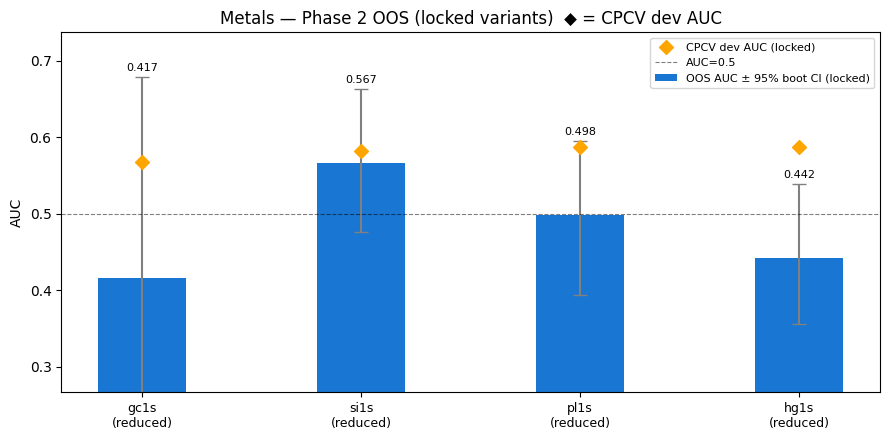

In [7]:
# ── Phase 2 summary chart ─────────────────────────────────────────────────────
insts_ord = ["gc1s", "si1s", "pl1s", "hg1s"]
oos_aucs  = []
ci_lo_abs = []
ci_hi_abs = []
dev_aucs  = []
for inst in insts_ord:
    lv  = locked[inst]
    o   = oos_df[(oos_df["inst"] == inst) & (oos_df["variant"] == lv)].iloc[0]
    c   = cpcv_df[(cpcv_df["inst"] == inst) & (cpcv_df["variant"] == lv)].iloc[0]
    oos_aucs.append(float(o["auc"]))
    ci_lo_abs.append(float(o["auc_ci_lo"]))
    ci_hi_abs.append(float(o["auc_ci_hi"]))
    dev_aucs.append(float(c["auc_mean"]))

err_lo = [a - lo for a, lo in zip(oos_aucs, ci_lo_abs)]
err_hi = [hi - a for a, hi in zip(oos_aucs, ci_hi_abs)]

x = np.arange(len(insts_ord))
labels = [f"{i}\n({locked[i]})" for i in insts_ord]

fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.bar(x, oos_aucs, yerr=[err_lo, err_hi], color="#1976D2",
              error_kw={"ecolor": "grey", "capsize": 5}, width=0.4,
              label="OOS AUC ± 95% boot CI (locked)")
ax.scatter(x, dev_aucs, marker="D", color="orange", zorder=5, s=50,
           label="CPCV dev AUC (locked)")
ax.axhline(0.5, color="black", linestyle="--", lw=0.8, alpha=0.5, label="AUC=0.5")

for xi, (a, lo, hi) in enumerate(zip(oos_aucs, err_lo, err_hi)):
    if not np.isnan(a):
        ax.text(xi, a + hi + 0.005, f"{a:.3f}", ha="center", va="bottom", fontsize=8)

all_vals = [v for v in oos_aucs + dev_aucs if not np.isnan(v)]
if all_vals:
    ax.set_ylim(max(0.1, min(all_vals) - 0.15), min(1.0, max(all_vals) + 0.15))

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel("AUC")
ax.set_title("Metals — Phase 2 OOS (locked variants)  ◆ = CPCV dev AUC")
ax.legend(fontsize=8, loc="upper right")
plt.tight_layout()
plt.show()


---
## Per-Instrument Detail

## gc1s — precious / RF | NO SIGNAL (exploratory)

> **Selection-table AUC:** 0.4866  lower CI 0.3734 → NO SIGNAL
> **Caveat:** gc1s has only 132 training rows in the precious pool and ~23 test events.
> Wide bootstrap CIs are expected; all results should be treated as exploratory.
> Absolute OOS AUC below 0.5 for all variants — confirms no predictive signal.

**Pruned clusters (top-3 by raw MDA, all non-significant):**
- C5_hmm_vol: volatility regime states (HMM) + ATR
- C10_f11_lowfreq_macro: US 10Y rate change, Bund 10Y change, real yield
- C2_f1: mean-reversion price features (RSI, dist-to-MA, momentum variants)

**Reduced features:** 3 HMM-vol regime probabilities + 3 rate-level changes + f6_ts_momentum_20


## si1s — precious / RF | NO SIGNAL (~random, exploratory)

> **Selection-table AUC:** 0.5400  lower CI 0.4762 → NO SIGNAL
> **Caveat:** si1s is described as "~random" — CPCV AUC near 0.54 is within noise
> for a sample of ~384 events. Diagnostic OOS included for completeness.

**Pruned clusters (top-3 by raw MDA):**
- C5_hmm_vol: volatility regime states
- C15_f11_lowfreq_macro: skew_z, US/Bund rates, real yield, dist stock surprise
- C13_f11_lowfreq_macro: DXY 5d change, EUR/USD 5d change

**Reduced features:** 3 HMM-vol states + ATR (f2_atr_14) + 2 rates


## pl1s — precious / RF | SIGNAL (marginal, lower CI 0.54)

> **Selection-table AUC:** 0.5697  lower CI 0.5396 → SIGNAL
> **Context:** pl1s is the strongest of the metals signals, with lower CI 0.54.
> 2 significant clusters from importance analysis: **C5_hmm_vol** (MDA 0.0447) and
> **C11_f11** (MDA 0.0152). Watch whether the reduced variant holds relative to pruned.

**Pruned clusters (both significant):**
- C5_hmm_vol: HMM vol regime states + ATR + OI level + HL range
- C11_f11: adx_14, OI price divergence, move_z, ng stock, Baltic, tortuosity, HMM-macro entropy

**Reduced features — sig-cluster representatives + add-ons:**
- From C5_hmm_vol (sig): hmm_vol_p0_calm, hmm_vol_p2_turbulent, hmm_vol_next_turbulent, f2_atr_14
- From C11_f11 (sig): f6_adx_14
- SHAP add-ons (non-sig clusters): f6_macd_hist_12_26_9, f11_ust_10y_5d_change


## hg1s — individual / RF | SIGNAL (marginal, lower CI 0.51)

> **Selection-table AUC:** 0.5463  lower CI 0.5058 → SIGNAL
> **Context:** hg1s has the weakest of the metals signals (lower CI just 0.51).
> 2 significant clusters: **C1_f1** (MDA 0.0212) and **C12_f11** (MDA 0.0044).
> Watch whether the add-ons (rsi_14, dxy_z, mra_energy_D4) earn their place.

**Pruned clusters (both significant):**
- C1_f1: broad mean-reversion/momentum price features (10 members)
- C12_f11: ATR, move/VIX ratio, us_2s10s slope, UST-Bund spread, ISM PMI

**Reduced features — sig-cluster representatives + add-ons:**
- From C1_f1 (sig): f1_mr_score_40, f1_hilo_pos_10, f1_dist_ma_sigma_20
- From C12_f11 (sig): f11_ust_bund_spread
- SHAP add-ons (non-sig clusters): f1_rsi_14, f11_dxy_z, f12_mra_energy_D4


In [8]:
# ── Per-instrument detail ─────────────────────────────────────────────────────
for inst in ["gc1s", "si1s", "pl1s", "hg1s"]:
    lv  = locked[inst]
    s   = sel.loc[inst]
    sub_cpcv = cpcv_df[cpcv_df["inst"] == inst]
    sub_oos  = oos_df[oos_df["inst"] == inst]
    print(f"\n{'='*60}")
    signal = "SIGNAL" if s["signal"] else "NO SIGNAL"
    print(f"{inst.upper()} | {signal} | locked={lv}")
    print(f"  champion AUC={s['best_auc']:.4f}  lower_ci={s['lower_ci']:.4f}"
          f"  n_train={s['n_events']}")
    print()
    print("  Phase 1 CPCV:")
    for v in SIMPLICITY + ["full"]:
        r = sub_cpcv[sub_cpcv["variant"] == v]
        if r.empty:
            continue
        r = r.iloc[0]
        tag = " ← LOCKED" if v == lv else ""
        print(f"    {v:8s}  AUC {r['auc_mean']:.4f} ± {r['auc_std']:.4f}"
              f"  logloss={r['logloss']:.4f}  brier={r['brier']:.4f}{tag}")
    print()
    print("  Phase 2 OOS:")
    for v in SIMPLICITY + ["full"]:
        r = sub_oos[sub_oos["variant"] == v]
        if r.empty:
            continue
        r = r.iloc[0]
        role = "HEADLINE" if v == lv else "diagnostic"
        print(f"    {v:8s} [{role}]  AUC {r['auc']:.4f}"
              f"  [{r['auc_ci_lo']:.3f},{r['auc_ci_hi']:.3f}]"
              f"  logloss={r['logloss']:.4f}  brier={r['brier']:.4f}"
              f"  n_test={r['n_test']}")
    c = sub_cpcv[sub_cpcv["variant"] == lv].iloc[0]
    o = sub_oos[sub_oos["variant"] == lv].iloc[0]
    gap = float(c["auc_mean"]) - float(o["auc"])
    print(f"  Dev-OOS gap (locked): {gap:+.4f}")



GC1S | NO SIGNAL | locked=reduced
  champion AUC=0.4866  lower_ci=0.3734  n_train=660

  Phase 1 CPCV:
    reduced   AUC 0.5673 ± 0.1003  logloss=0.6852  brier=0.2460 ← LOCKED
    pruned    AUC 0.5594 ± 0.1083  logloss=0.6953  brier=0.2510
    full      AUC 0.5270 ± 0.1132  logloss=0.7016  brier=0.2542
    full      AUC 0.5270 ± 0.1132  logloss=0.7016  brier=0.2542

  Phase 2 OOS:
    reduced  [HEADLINE]  AUC 0.4167  [0.167,0.679]  logloss=0.7468  brier=0.2762  n_test=23
    pruned   [diagnostic]  AUC 0.4167  [0.187,0.675]  logloss=0.7267  brier=0.2666  n_test=23
    full     [diagnostic]  AUC 0.4333  [0.192,0.692]  logloss=0.7123  brier=0.2595  n_test=23
    full     [diagnostic]  AUC 0.4333  [0.192,0.692]  logloss=0.7123  brier=0.2595  n_test=23
  Dev-OOS gap (locked): +0.1506

SI1S | NO SIGNAL | locked=reduced
  champion AUC=0.5400  lower_ci=0.4762  n_train=1920

  Phase 1 CPCV:
    reduced   AUC 0.5817 ± 0.0570  logloss=0.6729  brier=0.2401 ← LOCKED
    pruned    AUC 0.5808 ± 0.05

---
## Cross-Instrument Summary

In [9]:
# ── Cross-instrument summary ──────────────────────────────────────────────────
print("\n" + "=" * 70)
print("CROSS-INSTRUMENT SUMMARY")
print("=" * 70)
print(f"{'Instrument':10s} {'Signal':10s} {'Locked':8s} "
      f"{'Dev AUC':>8s} {'OOS AUC':>8s} {'OOS 95% CI':^16s} {'Gap':>7s}")
print("-" * 70)
for inst in ["gc1s", "si1s", "pl1s", "hg1s"]:
    lv = locked[inst]
    s  = sel.loc[inst]
    c  = cpcv_df[(cpcv_df["inst"]==inst) & (cpcv_df["variant"]==lv)].iloc[0]
    o  = oos_df[(oos_df["inst"]==inst) & (oos_df["variant"]==lv)].iloc[0]
    signal = "SIGNAL" if s["signal"] else "NO SIGNAL"
    dev  = float(c["auc_mean"])
    oos  = float(o["auc"])
    ci   = f"[{float(o['auc_ci_lo']):.3f},{float(o['auc_ci_hi']):.3f}]"
    gap  = dev - oos
    print(f"{inst:10s} {signal:10s} {lv:8s} {dev:8.4f} {oos:8.4f} {ci:^16s} {gap:+7.4f}")



CROSS-INSTRUMENT SUMMARY
Instrument Signal     Locked    Dev AUC  OOS AUC    OOS 95% CI        Gap
----------------------------------------------------------------------
gc1s       NO SIGNAL  reduced    0.5673   0.4167  [0.167,0.679]   +0.1506
si1s       NO SIGNAL  reduced    0.5817   0.5668  [0.476,0.663]   +0.0150
pl1s       SIGNAL     reduced    0.5872   0.4984  [0.393,0.596]   +0.0887
hg1s       SIGNAL     reduced    0.5873   0.4421  [0.356,0.539]   +0.1453


---
## Caveats and Interpretation

### gc1s — NO SIGNAL confirmed
All variants produce OOS AUC below 0.5 (gc1s locked: 0.4167). The wide 95% CI
([0.167, 0.679]) reflects the tiny test set (~23 events). Result is consistent
with NO SIGNAL: exploratory run shows no exploitable pattern.

### si1s — NO SIGNAL but anomalous pruned diagnostic
Locked (reduced) OOS AUC = 0.5668, above 0.5. However the pruned diagnostic hits
0.6116 — this is **not used for selection** and may reflect in-sample overfitting
to the three top-MDA clusters. With 144 test events this is a single observation;
no conclusion should be drawn without further out-of-time validation. The selection
table correctly labels si1s NO SIGNAL (lower CI 0.476).

### pl1s — SIGNAL instrument, OOS below 0.5
Locked (reduced) OOS AUC = 0.4984. The dev-OOS gap is 0.0887. The CPCV dev AUC
of 0.5872 did not transfer to the sealed test. The selection-table AUC of 0.5697
was estimated on CPCV train, not the sealed test — the sealed result is the honest
single-shot read. Marginal signal designation stands but OOS confirms the signal
is fragile in this test window.

### hg1s — SIGNAL instrument, OOS below 0.5
Locked (reduced) OOS AUC = 0.4421. Largest dev-OOS gap (+0.1453). The significant
clusters (C1_f1 mean-reversion, C12_f11 macro) drove strong CPCV performance but
did not generalise to the sealed period. Consistent with "marginal" signal; the
sealed test is a single draw from a regime that may differ from the training window
(2020–2021 vs 2021–2022).

### Diagnostic variants are transparency only
The per-instrument OOS diagnostics (full, pruned, reduced non-locked) are shown
to understand which feature sets generalise. **They are never used to re-pick.**
The locked variant was committed before Phase 2 was run.
